In [1]:
from __future__ import print_function, division   # Ensures Python3 printing & division standard
import pandas as pd 
from pandas import Series, DataFrame 
from matplotlib import pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import confusion_matrix
import lightgbm as lgb
from lightgbm import early_stopping
import time
import shap
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings("ignore")

SavePlots = False

data = pd.DataFrame(np.genfromtxt('data_mice_encoded_aggr.csv', delimiter=',', names=True))

data["CLAIM_RATE"] = (
    data["CLAIM_COUNT"] / data["EXPOSURE"]
)

target = 'CLAIM_RATE'
#variables = data.columns

features = [
    col for col in data.columns
    if col not in ['CLAIM_COUNT', 'CLAIM_SIZE', 'CLAIM_SIZE_INDEX', 
                   'f0', 'POLICY', 'EXPOSURE', 'OUTER_WALLS', 'HEATING_TYPE', 
                   'WATER_SUPPLY_TYPE', 'ROOF_TYPE', 'CLAIM_RATE']
]

data = data[data["EXPOSURE"] > 0]

X = data[features]
y = data[target]

feature_names = np.array(X.columns)

exposure = data["EXPOSURE"]

In [16]:
#Feature set for claim size:
top10_feat = ['CONSTRUCTION_YEAR', 
              'HOUDEN10KM', 
              'DEDUCTIBLE', 
              'RESIDENTIAL_AREA', 
              'ROOF_TYPE_CAT_Thatched_Roof', 
              'BUILDINGS', 
              'WATER_SUPPLY_TYPE_CAT_Private_Water_Supply', 
              'BASEMENT_AREA', 
              'OUTER_WALLS_CAT_Brick_Walls', 
              'WATER_SUPPLY_TYPE_CAT_Water_Extraction_Plant']

top20_feat = top10_feat + [
    'OUTER_WALLS_CAT_Timber_Framing',
    'HEATING_TYPE_CAT_Central_Heating_Own_System',
    'OUTER_WALLS_CAT_Wood_Cladding', #remove because of corr w OUTER_WALLS_CAT_Brick_Walls
    'ROOF_TYPE_CAT_Fiber_Cement_Asbestos',
    'HEATING_TYPE_CAT_District_Heating', #remove because of corr w HEATING_TYPE_CAT_Central_Heating_Own_System
    'OUTER_WALLS_CAT_Lightweight_Concrete', #remove because of corr w OUTER_WALLS_CAT_Brick_Walls
    'HEATING_TYPE_CAT_Electric_Heating',
    #'YEAR', check with group
    'WETROOMS', #remove because of corr w RESIDENTIAL_AREA
    'HEATING_TYPE_CAT_Stove_Fireplace'
]

# Feature set for claim count
top20_perm = ['DEDUCTIBLE', 
              'RESIDENTIAL_AREA', 
              'CONSTRUCTION_YEAR', 
              'HEATING_TYPE_CAT_District_Heating', 
              'BUILDINGS', 
              'BASEMENT_AREA', 
              'HOUDEN10KM', 
              'WETROOMS', 
              'HEATING_TYPE_CAT_Stove_Fireplace', 
              'WATER_SUPPLY_TYPE_CAT_Water_Extraction_Plant', 
              'HEATING_TYPE_CAT_Central_Heating_Two_Units', 
              'ROOF_TYPE_CAT_Fiber_Cement_Asbestos', 
              'WATER_SUPPLY_TYPE_CAT_Public_Water_Supply', 
              'HEATING_TYPE_CAT_Electric_Heating', 
              'HEATING_TYPE_CAT_Central_Heating_Own_System', 
              'CONSERVATORY_AREA', 
              'ROOF_TYPE_CAT_Metal_Sheets', 
              'ROOF_TYPE_CAT_Thatched_Roof', 
              'WATER_SUPPLY_TYPE_CAT_Private_Water_Supply', 
              'HEATING_TYPE_CAT_Unknown']

# Feature set for claim rate
top10_feat_rate = ['DEDUCTIBLE',
                   'RESIDENTIAL_AREA', 
                   'HEATING_TYPE_CAT_District_Heating',
                   'CONSTRUCTION_YEAR',
                   'HOUDEN10KM',
                   'HEATING_TYPE_CAT_Heat_Pump',
                   'BUILDINGS',
                   'BASEMENT_AREA',
                   'ROOF_TYPE_CAT_Tar_Paper',
                   'WATER_SUPPLY_TYPE_CAT_Private_Water_Supply']


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor
from tqdm.auto import tqdm

TARGET_EXPOSURE = 90000
N_SIMULATIONS = 1000

data = pd.DataFrame(
    np.genfromtxt(
        "data_mice_encoded_aggr.csv",
        delimiter=",",
        names=True
    )
)

data = data[data["EXPOSURE"] > 0].copy()

data["CLAIM_RATE"] = (
    data["CLAIM_COUNT"] / data["EXPOSURE"]
)

# count_features = top20_perm
severity_features = top20_feat

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

# Rate model

rate_features = top10_feat_rate

X_rate = data[rate_features].astype(np.float32)

y_rate = np.log1p(
    data["CLAIM_RATE"].values
)

rate_model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(128, 128),
        alpha=0.002435030695326177,
        learning_rate_init=0.0003919806274240008,
        random_state=42,
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20
    ))
])

rate_model.fit(X_rate, y_rate)

rate_residuals = (
    y_rate -
    rate_model.predict(X_rate)
)

rate_sigma = np.std(rate_residuals)

print(f"Rate sigma: {rate_sigma:.6f}")

severity_data = data[
    data["CLAIM_COUNT"] > 0
].copy()

X_sev = severity_data[severity_features].astype(np.float32)

y_sev = np.log1p(
    severity_data["CLAIM_SIZE"].values
)

severity_model = CatBoostRegressor(
    iterations=2000,
    depth=5,
    learning_rate=0.010034645263691164,
    l2_leaf_reg=20,
    loss_function="MAE",
    verbose=0,
    random_seed=42
)

severity_model.fit(X_sev, y_sev)

sev_residuals = (
    y_sev -
    severity_model.predict(X_sev)
)

sev_sigma = np.std(sev_residuals)

severity_cap = np.percentile(
    severity_data["CLAIM_SIZE"],
    99.5
)

Rate sigma: 0.071602


In [19]:
print(f"Severity cap: {severity_cap:,.2f}")

Severity cap: 1,841,528.57


In [ ]:
portfolio_losses = []
portfolio_counts = []

for sim in tqdm(range(N_SIMULATIONS)):

    sampled_rows = []
    exposure_sum = 0

    while exposure_sum < TARGET_EXPOSURE:

        row = data.sample(
            n=1,
            replace=True
        )

        sampled_rows.append(row)

        exposure_sum += (
            row["EXPOSURE"].iloc[0]
        )

    portfolio = pd.concat(
        sampled_rows,
        ignore_index=True
    )

    # Rate model

    rate_log = rate_model.predict(
        portfolio[rate_features]
    )

    rate_log += np.random.normal(
        0,
        rate_sigma,
        size=len(rate_log)
    )

    rate_pred = np.expm1(rate_log)

    rate_pred = np.maximum(
        rate_pred,
        0
    )

    # Expected counts

    count_pred = (
        rate_pred *
        portfolio["EXPOSURE"].values
    )

    # Severity model

    sev_log = severity_model.predict(
        portfolio[severity_features]
    )

    sev_log += np.random.normal(
        0,
        sev_sigma,
        size=len(sev_log)
    )

    sev_pred = np.expm1(sev_log)

    sev_pred = np.minimum(
        sev_pred,
        severity_cap
    )

    # Aggregate results

    portfolio_count = np.sum(
        count_pred
    )

    portfolio_loss = np.sum(
        count_pred * sev_pred
    )

    portfolio_counts.append(
        portfolio_count
    )

    portfolio_losses.append(
        portfolio_loss
    )

portfolio_counts = np.array(
    portfolio_counts
)

portfolio_losses = np.array(
    portfolio_losses
)

  0%|          | 0/1000 [00:00<?, ?it/s]


===== AGGREGATE LOSS DISTRIBUTION =====
Mean Loss : 55,361,007.90
Std Loss  : 933,374.23
VaR95     : 56,959,331.04
VaR99     : 57,624,578.62
TVaR95    : 57,380,355.63
TVaR99    : 57,988,565.56
Min Loss  : 52,714,740.20
Max Loss  : 59,289,108.72


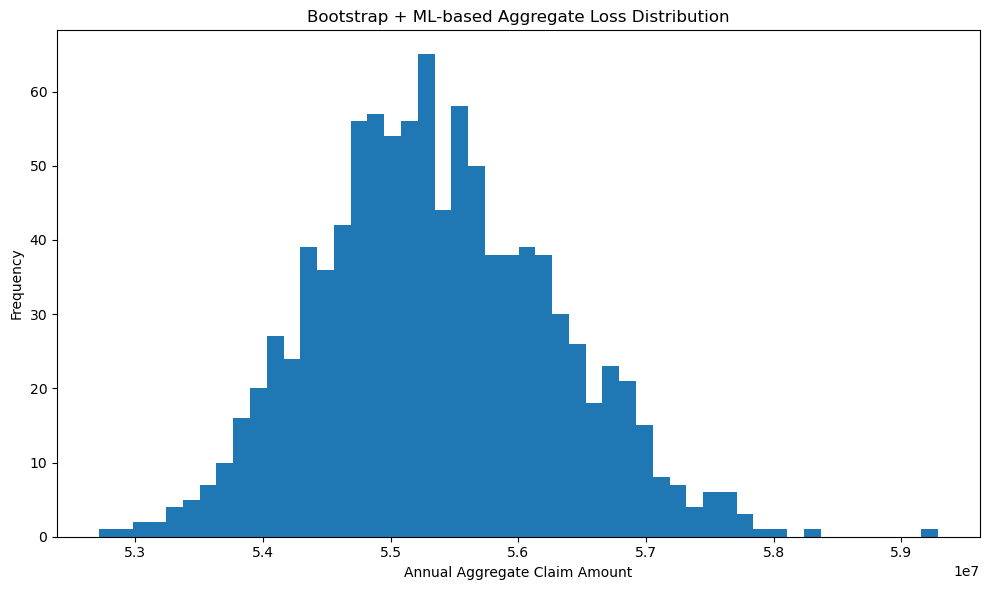

In [14]:
# summary

mean_loss = np.mean(portfolio_losses)
std_loss = np.std(portfolio_losses)

var95 = np.percentile(portfolio_losses, 95)
var99 = np.percentile(portfolio_losses, 99)

tvar95 = portfolio_losses[portfolio_losses >= var95].mean()
tvar99 = portfolio_losses[portfolio_losses >= var99].mean()

print("\n===== AGGREGATE LOSS DISTRIBUTION =====")
print(f"Mean Loss : {mean_loss:,.2f}")
print(f"Std Loss  : {std_loss:,.2f}")
print(f"VaR95     : {var95:,.2f}")
print(f"VaR99     : {var99:,.2f}")
print(f"TVaR95    : {tvar95:,.2f}")
print(f"TVaR99    : {tvar99:,.2f}")
print(f"Min Loss  : {portfolio_losses.min():,.2f}")
print(f"Max Loss  : {portfolio_losses.max():,.2f}")

# plot

plt.figure(figsize=(10, 6))
plt.hist(portfolio_losses, bins=50)
plt.xlabel("Annual Aggregate Claim Amount")
plt.ylabel("Frequency")
plt.title("Bootstrap + ML-based Aggregate Loss Distribution")
plt.tight_layout()
plt.show()

# Claim rate * claim size with penalty

In [21]:
#Feature set for claim size:
top_unique = ['CONSTRUCTION_YEAR', 
              'HOUDEN10KM', 
              'DEDUCTIBLE', 
              'RESIDENTIAL_AREA', 
              'ROOF_TYPE_CAT_Thatched_Roof', 
              'BUILDINGS', 
              'WATER_SUPPLY_TYPE_CAT_Private_Water_Supply', 
              'BASEMENT_AREA', 
              'OUTER_WALLS_CAT_Brick_Walls', 
              'HEATING_TYPE_CAT_Central_Heating_Own_System',
              'WETROOMS']

# Feature set for claim rate
top10_feat_rate = ['DEDUCTIBLE',
                   'RESIDENTIAL_AREA', 
                   'HEATING_TYPE_CAT_District_Heating',
                   'CONSTRUCTION_YEAR',
                   'HOUDEN10KM',
                   'HEATING_TYPE_CAT_Heat_Pump',
                   'BUILDINGS',
                   'BASEMENT_AREA',
                   'ROOF_TYPE_CAT_Tar_Paper',
                   'WATER_SUPPLY_TYPE_CAT_Private_Water_Supply']


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor
from tqdm.auto import tqdm

TARGET_EXPOSURE = 90000
N_SIMULATIONS = 1000

data = pd.DataFrame(
    np.genfromtxt(
        "data_mice_encoded_aggr.csv",
        delimiter=",",
        names=True
    )
)

data = data[data["EXPOSURE"] > 0].copy()

data["CLAIM_RATE"] = (
    data["CLAIM_COUNT"] / data["EXPOSURE"]
)

# count_features = top20_perm
severity_features = top_unique

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

# Rate model

rate_features = top10_feat_rate

X_rate = data[rate_features].astype(np.float32)

y_rate = np.log1p(
    data["CLAIM_RATE"].values
)

rate_model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(128, 128),
        alpha=0.002435030695326177,
        learning_rate_init=0.0003919806274240008,
        random_state=42,
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20
    ))
])

rate_model.fit(X_rate, y_rate)

rate_residuals = (
    y_rate -
    rate_model.predict(X_rate)
)

rate_sigma = np.std(rate_residuals)

print(f"Rate sigma: {rate_sigma:.6f}")

severity_data = data[
    data["CLAIM_COUNT"] > 0
].copy()

X_sev = severity_data[severity_features].astype(np.float32)

y_sev = severity_data["CLAIM_SIZE_INDEX"].values

severity_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(
        hidden_layer_sizes=(64, 64),
        alpha=0.0008898416750158575,
        learning_rate_init=0.0006263298840589133,
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=42
    ))
])

severity_model.fit(X_sev, y_sev)

sev_residuals = (y_sev -severity_model.predict(X_sev))

sev_sigma = np.std(sev_residuals)

severity_cap = np.percentile(
    severity_data["CLAIM_SIZE_INDEX"],
    99.5
)

Rate sigma: 0.063670


In [25]:
portfolio_losses = []
portfolio_counts = []

for sim in tqdm(range(N_SIMULATIONS)):

    sampled_rows = []
    exposure_sum = 0

    while exposure_sum < TARGET_EXPOSURE:

        row = data.sample(n=1,replace=True)

        sampled_rows.append(row)

        exposure_sum += (row["EXPOSURE"].iloc[0])

    portfolio = pd.concat(sampled_rows,ignore_index=True)

    # Rate model
    rate_log = rate_model.predict(portfolio[rate_features])
    rate_log += np.random.normal(0,rate_sigma,size=len(rate_log))
    rate_pred = np.expm1(rate_log)
    rate_pred = np.maximum(rate_pred,0)

    # Expected counts
    count_pred = (rate_pred * portfolio["EXPOSURE"].values)

    # Severity model
    sev_pred = severity_model.predict(portfolio[severity_features])
    sev_pred += np.random.normal(0,sev_sigma,size=len(sev_pred))
    sev_pred = np.minimum(sev_pred,severity_cap)

    # Aggregate results
    portfolio_count = np.sum(count_pred)
    portfolio_loss = np.sum(count_pred * sev_pred)
    portfolio_counts.append(portfolio_count)
    portfolio_losses.append(portfolio_loss)

portfolio_counts = np.array(portfolio_counts)
portfolio_losses = np.array(portfolio_losses)

  0%|          | 0/1000 [00:00<?, ?it/s]


===== AGGREGATE LOSS DISTRIBUTION =====
Mean Loss : 103,042,586.43
Std Loss  : 7,986,604.67
VaR95     : 116,597,423.36
VaR99     : 122,795,139.22
TVaR95    : 120,354,975.24
TVaR99    : 127,158,411.62
Min Loss  : 76,961,497.73
Max Loss  : 133,062,345.21


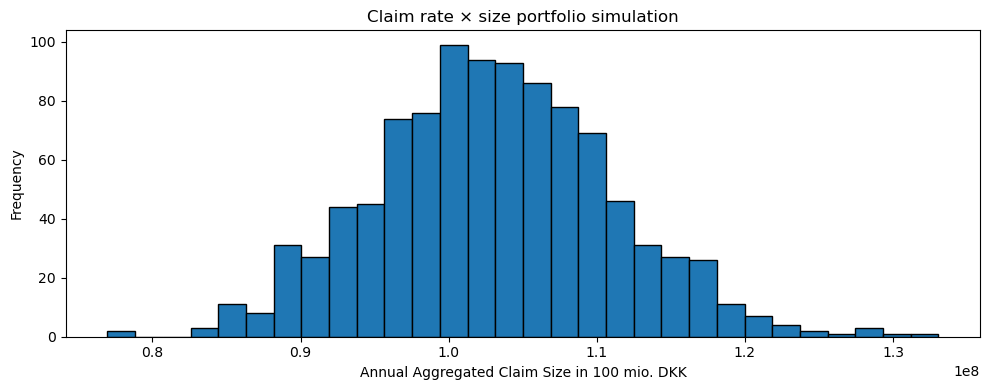

In [26]:
# summary

mean_loss = np.mean(portfolio_losses)
std_loss = np.std(portfolio_losses)

var95 = np.percentile(portfolio_losses, 95)
var99 = np.percentile(portfolio_losses, 99)

tvar95 = portfolio_losses[portfolio_losses >= var95].mean()
tvar99 = portfolio_losses[portfolio_losses >= var99].mean()

print("\n===== AGGREGATE LOSS DISTRIBUTION =====")
print(f"Mean Loss : {mean_loss:,.2f}")
print(f"Std Loss  : {std_loss:,.2f}")
print(f"VaR95     : {var95:,.2f}")
print(f"VaR99     : {var99:,.2f}")
print(f"TVaR95    : {tvar95:,.2f}")
print(f"TVaR99    : {tvar99:,.2f}")
print(f"Min Loss  : {portfolio_losses.min():,.2f}")
print(f"Max Loss  : {portfolio_losses.max():,.2f}")

# plot

plt.figure(figsize=(10, 4))
plt.hist(
    portfolio_losses,
    bins=30,
    edgecolor="black",
    linewidth=1
)
plt.xlabel("Annual Aggregated Claim Size in 100 mio. DKK")
plt.ylabel("Frequency")
plt.title("Claim rate × size portfolio simulation")
plt.tight_layout()
plt.show()